# Molecular dynamics simulations of a Lennard-Jones-like liquid

In a classical approximation, interactions between atoms consist of a repulsive term due to electron shell overlap and an attractive term due to dipole-dipole interactions. These terms are typically parametrized by the Lennard-Jones potential. For computational convenience, we use the Wang-Frenkel interaction potential between particles $i$ and $j$ instead


$$
U_{ij}^{\mathrm{WF}} =
\begin{cases}
\epsilon \left[ \left( \frac{\sigma}{r_{ij}} \right)^2 - 1 \right]
\left[ \left( \frac{r_c}{r_{ij}} \right)^2 - 1 \right]^2 & \text{if } r_{ij} < r_c \\
0 & \text{otherwise.}
\end{cases}
$$

with $\sigma$ and $\epsilon$ being phenomenological constants and $r_c$ being the cutoff distance. The distance between molecules is denoted $r_{ij}$. We consider a two-dimensional system of spherical molecules with periodic boundary conditions. The molecules all have the same mass $m$.

## 1. Initialization

### (a)

Write a script to generate the positions of a two-dimensional system of molecules with a packing fraction $\phi$, which is defined as

$$
\phi = \frac{N \pi \sigma^2}{A},
$$
with $N$ being the number of molecules and $A$ being the total surface area of
two-dimensional system. Make sure that the molecules do not overlap because
that would lead to very large energies

In [2]:
#1a
import numpy as np
import matplotlib.pyplot as plt 

#Constants
sigma = 1.0
rc = 2.5
epsilon = 1.0
phi = 0.3

#Parameter
N = 100

#function to generate positions with the given tensity -> this variant is very slow 
def generate_positions(N, phi, sigma, factor = 1.0, max_trials=100000):
    positions = []
    cnt = 0

    #calculate A for the chosen N and sigma
    A = (N*np.pi*sigma**2) / phi 

    #quadradic field with sidelenght L
    L = np.sqrt(A)

    #calc minimal distance between two moleculecenters
    min_distance = 2* sigma * factor

    #try as long as their are N molecules or max_tails is reached
    while len(positions) < N and cnt < max_trials:
        p = np.array([np.random.uniform(0, L),
                      np.random.uniform(0, L)])

        # check if their is an overlap
        ok = True
        for q in positions:
            if np.linalg.norm(p - q) < min_distance:
                ok = False
                break

        if ok:
            positions.append(p)

        cnt += 1

    # if the number of paricles cannot be reached within the max 
    # nuber of trails stopp with the error 
    if len(positions) < N:
        raise RuntimeError("density not reachable.")

    return np.array(positions), L


#function to generate positions with the given tensity, vectorized 
def generate_positions_v(N, phi, sigma, factor=1.0, max_trials=100000):
    #create empty arry
    positions = np.empty((2, 0))
    cnt = 0

    # calc A / L  for the chosen density
    A = (N * np.pi * sigma**2) / phi
    L = np.sqrt(A)

    # calc minimal distances between the molecule centers
    min_distance = 2 * sigma * factor

    # create N positions
    while positions.shape[1] < N and cnt < max_trials:
        cnt += 1

        #random guess of new positons
        p = np.array([
            np.random.uniform(0, L),
            np.random.uniform(0, L)
        ])

        # first iteration ?
        if positions.shape[1] == 0:
            positions = np.column_stack((positions, p))
            continue

        # deltas from every existing particel to the new guess
        delta = positions - p[:,np.newaxis]

        # calc distance
        distances = np.sqrt(delta[0, :]**2 + delta[1, :]**2)

        # is the particle in the critical region of another particle? 
        if np.all(distances >= min_distance):
            positions = np.column_stack((positions, p))

    # if N not reached -> error message
    if positions.shape[1] < N:
        raise RuntimeError("density not reachable.")
    
    # transpose 
    positions = positions.T
    return positions, L


#positions, L = generate_positions(N, phi, sigma, 1.0, 1000000)
positions, L = generate_positions_v(N, phi, sigma, 1.0, 1000000)

print("Box length L =", L)
print("Generated positions:")
print(positions)
print(positions.shape)



Box length L = 32.36043187592832
Generated positions:
[[ 5.88615968 29.57885474]
 [ 9.14390389  1.70654286]
 [ 2.06307334  8.81233073]
 [16.62812326 21.30214902]
 [22.14676689 15.48360066]
 [28.09113436 12.44558723]
 [24.86093721 16.23598951]
 [19.87620434  1.09803528]
 [18.6369556  12.20716167]
 [ 8.20757274 20.06437443]
 [13.27106217 25.12382562]
 [24.65715454 18.49530205]
 [30.96073957 16.95713509]
 [10.0906517  23.16809753]
 [13.95114487 31.48473597]
 [19.70304727 30.59597468]
 [ 1.206724    6.68015981]
 [ 1.79929562 27.89210216]
 [ 3.33595881 17.30671339]
 [ 4.8517465  23.83387141]
 [ 8.44560679  4.47178747]
 [13.71333756 16.85640782]
 [29.10978403 26.47589598]
 [24.34431108 22.37449106]
 [13.20105702 14.39730861]
 [ 2.06829442  4.1738014 ]
 [ 4.57251687  1.32652435]
 [23.55523912  7.94871771]
 [27.84934089 31.94292165]
 [ 2.65672361 32.04873445]
 [19.97739466  6.50377628]
 [20.78810604 28.87501788]
 [31.85371847 20.01340548]
 [21.94686209 23.06358293]
 [21.2242695  17.38782943]
 

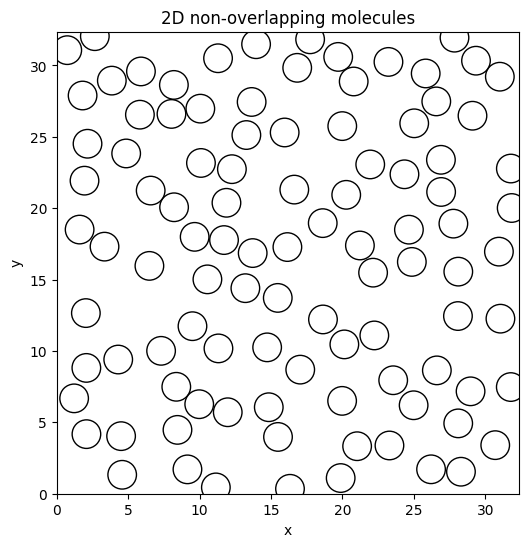

In [3]:
#Testfeld
#plot particles
fig, ax = plt.subplots(figsize=(6, 6))

for x, y in positions:
    circle = plt.Circle((x, y), sigma, fill=False)
    ax.add_patch(circle)

ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_aspect('equal')
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("2D non-overlapping molecules")
plt.show()

(b) Generate initial velocities for all particles by drawing independent velocities
in every dimension from a Gaussian distribution corresponding to an initial
temperature $T$ . Make sure that the velocity of the center of mass of the system
vanishes.

In [4]:
#1b
# function to generate the velocities
def generate_velocities(N, T, k_B, m):
    # for corresbondig to a Temp use a sigma_v(T)
    # Äquipartitionstheorem 1/2 kb T per dimension
    sigma_v = np.sqrt(k_B*T/m)
    # create velocities
    v = np.random.normal(0.0, sigma_v, size=(N, 2))
    # subtract center-of-mass velocity
    v_cm = np.mean(v, axis=0)
    v_cm_corr = v - v_cm

    return v, v_cm_corr 

# check the function (vanishes v of des center of mass)
N = 100
m =1.0
k_B = 1.0
T = 1.0

v, v_cm_corr = generate_velocities(N, T, k_B, m)
print("Number of Values", np.shape(v))
print("Means of  direction (without COM correction):", np.mean(v, axis=0))
print("Means of  direction (with COM correction):", np.mean(v_cm_corr, axis=0))
#print(positions)


Number of Values (100, 2)
Means of  direction (without COM correction): [-0.13465158  0.02656878]
Means of  direction (with COM correction): [ 3.10862447e-17 -1.11022302e-17]


2 Force calculation
The force between the molecules is given as usual by $f_{ij} = −\nabla U^{WF}_{ij}$ . The forces
are assumed to be pairwise additive.

    (a) Write a script to calculate the force on all particles from the positions of the particles. Take care that periodic boundary conditions are used.


In [5]:
#2a
def pair_force(vec_rij, epsilon, sigma, rc):
    # absolutvalue of the vector rij
    r = np.sqrt(np.dot(vec_rij,vec_rij))

    # chec if inside the cutoff distance (avoid division 0 )
    if r >= rc or r < 1e-48:
        return np.zeros(2)
    
    # calculate a force
    A = (sigma**2 / r**2) -1.0
    B = (rc**2 / r**2) -1.0
    
    f = vec_rij * (2*epsilon/r**4) * (sigma**2 * B**2 + 2 * A * B * rc**2)
    return f

# test the function
#rc = 10
#i = 0
#j = 6
#rij = positions[i]-positions[j]
#r = np.linalg.norm(rij)
#f = pair_force(rij, epsilon, sigma, rc)
#print(rij)
#print(r)
#print(f)
#print(positions)

# calculate total forces
def total_forces(positions, L, epsilon, sigma, rc):
    N = len(positions)
    forces = np.zeros_like(positions)
    U_tot = 0
    # seite 79 im scirpt!
    for i in range(N - 1):
        for j in range(i + 1, N):
            rij = positions[i] - positions[j]
            # this is to have periodic poundary conditions
            rij -= L * np.round(rij / L)
            fij  = pair_force(rij, epsilon, sigma, rc)
            # add force to i
            forces[i] += fij
            # same force accts with opposite sign to j
            forces[j] -= fij

    return forces

# Test of te funciton
rc = 1.5
f_tot = total_forces(positions, L, epsilon, sigma, rc)
idx = np.where(np.linalg.norm(f_tot, axis=1) != 0)[0]
print(L)
print(f_tot[idx])


32.36043187592832
[]


        (b) Include a calculation of the total potential energy of the system in the calculation
of the forces

In [6]:
#2b
def pair_force_potential_Energy(vec_rij, epsilon, sigma, rc):
    # absolutvalue of the vector rij
    r = np.sqrt(np.dot(vec_rij,vec_rij))

    # chec if inside the cutoff distance (avoid division 0 )
    if r >= rc or r < 1e-48:
        return np.zeros(2)
    
    # calculate a force
    A = (sigma**2 / r**2) -1.0
    B = (rc**2 / r**2) -1.0
    f = vec_rij * (2*epsilon/r**4) * (sigma**2 * B**2 + 2 * A * B * rc**2)

    # calc E Pot
    U = epsilon*A*B**2
    return f, U

# sum up forces and energys 
def total_forces_Energy(positions, L, epsilon, sigma, rc):
    N = len(positions)
    forces = np.zeros_like(positions)
    U_tot = 0
    # seite 79 im scirpt!
    for i in range(N - 1):
        for j in range(i + 1, N):
            rij = positions[i] - positions[j]
            # this is to have periodic poundary conditions
            rij -= L * np.round(rij / L)
            fij, Uij  = pair_force_potential_Energy(rij, epsilon, sigma, rc)
            # add force to i
            forces[i] += fij
            # same force accts with opposite sign to j
            forces[j] -= fij
            # summ up potential Energy
            U_tot += Uij
    return forces, U_tot

# Test of te funciton
rc = 2.5
f_tot, U_tot = total_forces_Energy(positions, L, epsilon, sigma, rc)
idx = np.where(np.linalg.norm(f_tot, axis=1) != 0)[0]
print(L)
print(f_tot[idx])
print(U_tot)


32.36043187592832
[[-6.65881494e-01 -2.14918432e-01]
 [ 1.62329635e-01 -1.03041235e-01]
 [ 1.59459918e-01 -2.08339082e-01]
 [-3.39420868e-01  7.00636109e-01]
 [-3.25433583e-02  3.60804066e-01]
 [ 1.91331060e-01 -2.23318804e-01]
 [-9.55879157e-01  6.82038695e-01]
 [ 3.32679691e-02  2.08913878e-01]
 [ 3.25433583e-02 -3.60804066e-01]
 [ 4.90468537e-01 -9.84536200e-02]
 [ 3.61051198e-01 -7.82269780e-01]
 [-1.26962663e+00  8.95665408e-01]
 [ 2.68199693e-01  1.36616551e-01]
 [-6.42726720e-01  4.40167551e-01]
 [ 1.24937173e-01  1.47530465e-01]
 [-4.31767783e-01  2.18609665e-01]
 [-5.71621646e-03  1.64299566e-03]
 [ 1.65920720e-01 -4.98360780e-02]
 [ 8.13341523e-02 -4.70752963e-03]
 [ 2.37602174e-01 -2.90912162e-01]
 [ 6.16508129e-01  7.90677160e-01]
 [-5.57113079e-01 -2.82753477e-01]
 [-5.79499182e-01  9.19114328e-01]
 [ 5.71621646e-03 -1.64299566e-03]
 [ 3.39420868e-01 -7.00636109e-01]
 [ 9.26848587e-01 -7.03702187e-01]
 [ 4.16761598e-01  4.13421225e-01]
 [-2.37602174e-01  2.90912162e-01]
 [

(c) Evaluate the scaling of computational cost of the force calculation with the num-
ber of particles $N$ .

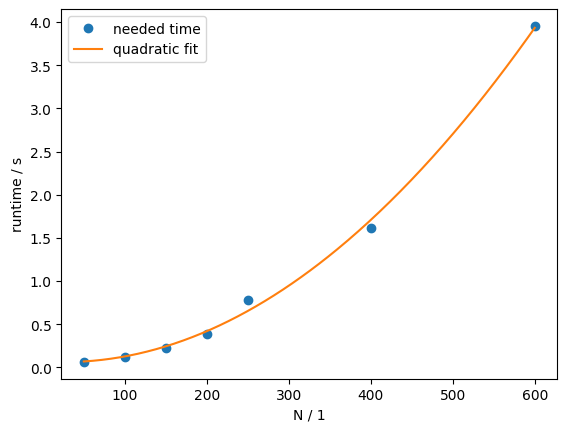

Fit: t(N) = a*N^2 + b*N + c
a = 1.1714528421339678e-05
b = -0.0005903934684889933
c = 0.06935630468937805


In [10]:
#2c
import time
N_values = [50,100,150,200,250,400,600] 
times = []
repeats = 2 # per N_value

for N in N_values:
    positions, L = generate_positions_v(N, phi, sigma, 1.0, 1000000)
    # list for times with same N to calc mean
    t_list =[]
    # do this for the number of repeats
    for _ in range(repeats):
        t0 = time.perf_counter()
        f  = total_forces(positions, L, epsilon, sigma, rc)
        t1 = time.perf_counter()
        t_list.append(t1-t0)
    # calc mean of all times for same n
    times.append(np.mean(t_list)) 

# crate a fit to show its quatratic 
times = np.array(times)
N_values_plot = np.array(N_values)
coeff = np.polyfit(N_values_plot, times, 2)
a, b, c = coeff
N_fit = np.linspace(N_values_plot.min(), N_values_plot.max(), 300)
t_fit = a * N_fit**2 + b * N_fit + c

plt.plot(N_values_plot, times, 'o', label='needed time')
plt.plot(N_fit, t_fit, '-', label='quadratic fit')
plt.xlabel('N / 1')
plt.ylabel('runtime / s')
plt.legend()
plt.show()

print("Fit: t(N) = a*N^2 + b*N + c")
print("a =", a)
print("b =", b)
print("c =", c)


3 Integration of the equations of motion

(a)

Nondimensionalize the equations and pick a sensible time step in terms of $\sigma$, $\epsilon$ and the particle mass $m$.

The velocity-Verlet algorithm for positions $r$, velocities $v$ and forces $f$ consists of the following steps:

$$
v\left(t + \frac{\Delta t}{2}\right) = v(t) + \frac{f(t)}{2m}\Delta t
$$

$$
r(t + \Delta t) = r(t) + v\left(t + \frac{\Delta t}{2}\right)\Delta t
$$

$$
f(t + \Delta t) = f(r(t + \Delta t))
$$

$$
v(t + \Delta t) = v\left(t + \frac{\Delta t}{2}\right) + \frac{f(t+\Delta t)}{2m}\Delta t
$$


In [ ]:
#3a
# no code required

Die Antwort sind mehr oder weniger nur Formeln

(b)

Implement the velocity-Verlet algorithm to solve the equations of motion.

In [ ]:
#3b
def velocity_verlet(pos, vel, L, n_steps, dt, epsilon, sigma, rc, m):
    # use N of pos
    N = len(pos)

    # calculate forces and Potential energy
    forces, U = total_forces_Energy(pos, L, epsilon=epsilon, sigma=sigma, rc=rc)

    # initalize arrays for energys
    E_kin_hist = np.zeros(n_steps)
    E_pot_hist = np.zeros(n_steps)
    E_tot_hist = np.zeros(n_steps)
    T_hist = np.zeros(n_steps)
    pos_hist = np.zeros((n_steps, N, 2))


    for i in range(n_steps):
        # calc fist velocity halfstep
        vel_half = vel + 0.5 * forces / m * dt

        # Full-step position
        pos = pos + vel_half * dt

        # Pos Modulo L is used for periodic boundary conditions
        pos = pos % L

        # New forces forces after step
        forces_new, U = total_forces_Energy(pos, L, epsilon=epsilon, sigma=sigma, rc=rc)

        # Full-step velocity
        vel = vel_half + 0.5 * forces_new / m * dt

        # Update forces
        forces = forces_new

        # calc kinetic enerty
        E_kin = 0.5 * m * np.sum(vel**2)

        # Temperature in 2D
        # degrees of freedom = 2N - 2
        dof = 2 * N - 2
        T = 2 * E_kin / dof

        E_kin_hist[i] = E_kin
        E_pot_hist[i] = U
        E_tot_hist[i] = E_kin + U
        T_hist[i] = T

        pos_hist[i] = pos
        print(i, "/",n_steps)
    return pos, vel, pos_hist, E_kin_hist, E_pot_hist, E_tot_hist, T_hist

(c)

Calculate the kinetic energy at every integer time step and plot the total energy and the temperature as a function of time.

0 / 1000
1 / 1000
2 / 1000
3 / 1000
4 / 1000
5 / 1000
6 / 1000
7 / 1000
8 / 1000
9 / 1000
10 / 1000
11 / 1000
12 / 1000
13 / 1000
14 / 1000
15 / 1000
16 / 1000
17 / 1000
18 / 1000
19 / 1000
20 / 1000
21 / 1000
22 / 1000
23 / 1000
24 / 1000
25 / 1000
26 / 1000
27 / 1000
28 / 1000
29 / 1000
30 / 1000
31 / 1000
32 / 1000
33 / 1000
34 / 1000
35 / 1000
36 / 1000
37 / 1000
38 / 1000
39 / 1000
40 / 1000
41 / 1000
42 / 1000
43 / 1000
44 / 1000
45 / 1000
46 / 1000
47 / 1000
48 / 1000
49 / 1000
50 / 1000
51 / 1000
52 / 1000
53 / 1000
54 / 1000
55 / 1000
56 / 1000
57 / 1000
58 / 1000
59 / 1000
60 / 1000
61 / 1000
62 / 1000
63 / 1000
64 / 1000
65 / 1000
66 / 1000
67 / 1000
68 / 1000
69 / 1000
70 / 1000
71 / 1000
72 / 1000
73 / 1000
74 / 1000
75 / 1000
76 / 1000
77 / 1000
78 / 1000
79 / 1000
80 / 1000
81 / 1000
82 / 1000
83 / 1000
84 / 1000
85 / 1000
86 / 1000
87 / 1000
88 / 1000
89 / 1000
90 / 1000
91 / 1000
92 / 1000
93 / 1000
94 / 1000
95 / 1000
96 / 1000
97 / 1000
98 / 1000
99 / 1000
100 / 1000

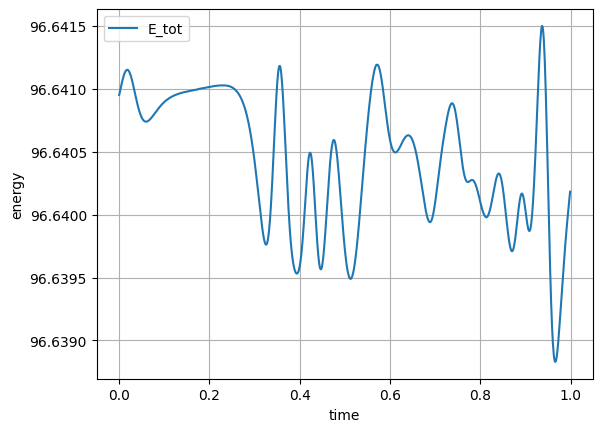

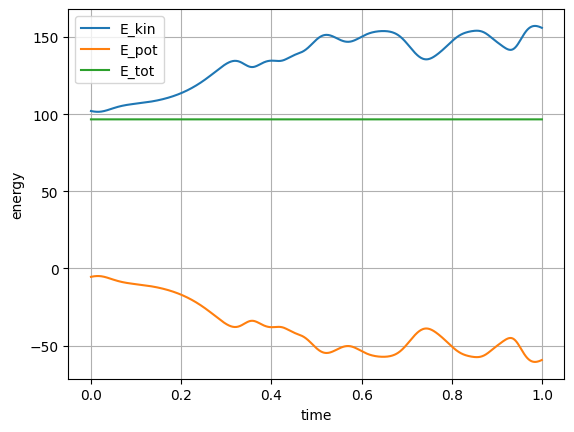

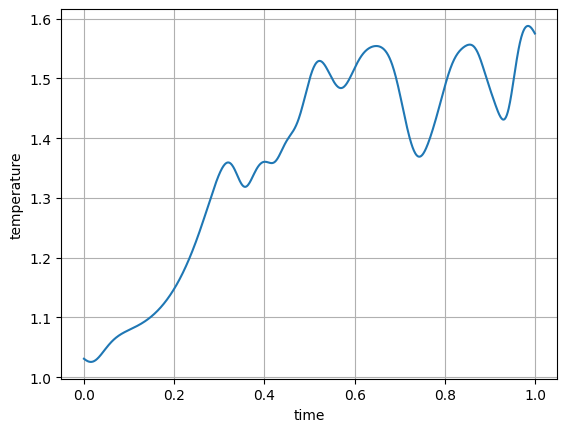

In [ ]:
#3c
# Example parameters
N = 100
sigma = 1.0
epsilon = 1.0
m = 1.0
rc = 2.5
phi = 0.3
dt = 0.001
n_steps = 1000

positions, L = generate_positions_v(N, phi, sigma, 1.0, 1000000)
_, v = generate_velocities(N, 1, 1, m)

pos, vel, pos_hist, E_kin_hist, E_pot_hist, E_tot_hist, T_hist = velocity_verlet(
    positions,v, L,
    n_steps=n_steps,
    dt=dt,
    epsilon=epsilon,
    sigma=sigma,
    rc=rc,
    m=m
)

time = np.arange(n_steps) * dt

plt.figure()
plt.plot(time, E_tot_hist, label="E_tot")
plt.xlabel("time")
plt.ylabel("energy")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(time, E_kin_hist, label="E_kin")
plt.plot(time, E_pot_hist, label="E_pot")
plt.plot(time, E_tot_hist, label="E_tot")
plt.xlabel("time")
plt.ylabel("energy")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(time, T_hist)
plt.xlabel("time")
plt.ylabel("temperature")
plt.grid()
plt.show()